In [1]:
!pip install shap -q

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

random.seed(42)
np.random.seed(42)

print("Libraries imported successfully!")
print("SHAP version:", shap.__version__)

Libraries imported successfully!
SHAP version: 0.52.0


In [3]:
train_df = pd.read_csv(
    "train_fraud_balanced.csv"
)

validation_df = pd.read_csv(
    "validation_fraud_dataset.csv"
)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

Training shape: (79328, 45)
Validation shape: (8648, 45)


In [4]:
print("TRAINING COLUMNS")
print("=" * 50)

print(train_df.columns.tolist())

print("\nVALIDATION COLUMNS")
print("=" * 50)

print(validation_df.columns.tolist())

TRAINING COLUMNS
['transaction_id', 'transaction_date', 'customer_id', 'card_type', 'amount', 'merchant_category', 'merchant_country', 'transaction_channel', 'device_type', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'is_fraud', 'transaction_hour', 'transaction_day', 'transaction_month', 'dataset_source', 'sender_account_id', 'receiver_account_id', 'transaction_type', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'customer_age_group', 'customer_city', 'kyc_level', 'login_attempts', 'account_age_days', 'product_category', 'payment_method', 'billing_country', 'shipping_country', 'email_age_days', 'ip_risk_level', 'failed_payment_attempts', 'delivery_speed', 'customer_balance', 'location', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location']

VALIDATION COLUMNS
['transaction_id', 'transaction_date', 'customer_id', 'card_type', 'amount', 'merchant_catego

In [6]:
target_column = "is_fraud"

if target_column not in train_df.columns:
    raise ValueError(
        "'is_fraud' is missing from training dataset."
    )

if target_column not in validation_df.columns:
    raise ValueError(
        "'is_fraud' is missing from validation dataset."
    )

print("Target column:", target_column)

print("\nTraining target distribution:")
print(
    train_df[target_column].value_counts()
)

print("\nValidation target distribution:")
print(
    validation_df[target_column].value_counts()
)

Target column: is_fraud

Training target distribution:
is_fraud
0    39664
1    39664
Name: count, dtype: int64

Validation target distribution:
is_fraud
0    8499
1     149
Name: count, dtype: int64


In [7]:
X_train = train_df.drop(
    columns=[target_column]
).copy()

y_train = pd.to_numeric(
    train_df[target_column],
    errors="coerce"
)

X_validation = validation_df.drop(
    columns=[target_column]
).copy()

y_validation = pd.to_numeric(
    validation_df[target_column],
    errors="coerce"
)

common_columns = [
    column
    for column in X_train.columns
    if column in X_validation.columns
]

X_train = X_train[
    common_columns
].copy()

X_validation = X_validation[
    common_columns
].copy()

for column in common_columns:

    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce"
    )

    X_validation[column] = pd.to_numeric(
        X_validation[column],
        errors="coerce"
    )

usable_columns = [
    column
    for column in X_train.columns
    if X_train[column].notna().any()
]

X_train = X_train[
    usable_columns
].copy()

X_validation = X_validation[
    usable_columns
].copy()

print(
    "Number of usable features:",
    len(usable_columns)
)

print(
    usable_columns
)

Number of usable features: 22
['amount', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'transaction_hour', 'transaction_day', 'transaction_month', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'login_attempts', 'account_age_days', 'email_age_days', 'failed_payment_attempts', 'customer_balance', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location']


In [8]:
valid_train_rows = y_train.notna()

valid_validation_rows = (
    y_validation.notna()
)

X_train = (
    X_train
    .loc[valid_train_rows]
    .reset_index(drop=True)
)

y_train = (
    y_train
    .loc[valid_train_rows]
    .astype(int)
    .reset_index(drop=True)
)

X_validation = (
    X_validation
    .loc[valid_validation_rows]
    .reset_index(drop=True)
)

y_validation = (
    y_validation
    .loc[valid_validation_rows]
    .astype(int)
    .reset_index(drop=True)
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)

Training shape: (79328, 22)
Validation shape: (8648, 22)


In [9]:
training_medians = X_train.median()

X_train = (
    X_train
    .fillna(training_medians)
    .fillna(0)
)

X_validation = (
    X_validation
    .fillna(training_medians)
    .fillna(0)
)

print(
    "Training missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Validation missing values:",
    X_validation.isnull().sum().sum()
)

Training missing values: 0
Validation missing values: 0


In [10]:
assert list(
    X_train.columns
) == list(
    X_validation.columns
)

print(
    "Training and validation features are aligned."
)

print(
    "Total features:",
    X_train.shape[1]
)

Training and validation features are aligned.
Total features: 22


In [11]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=1
)

random_forest_model.fit(
    X_train,
    y_train
)

print(
    "Day 17 Random Forest recreated successfully."
)

Day 17 Random Forest recreated successfully.


In [12]:
rf_fraud_probability = (
    random_forest_model
    .predict_proba(
        X_validation
    )[:, 1]
)

print(
    "Fraud probability minimum:",
    rf_fraud_probability.min()
)

print(
    "Fraud probability maximum:",
    rf_fraud_probability.max()
)

Fraud probability minimum: 0.020394636941571617
Fraud probability maximum: 0.7977884997870435


In [13]:
explainer = shap.TreeExplainer(
    random_forest_model
)

print(
    "SHAP TreeExplainer created successfully."
)

SHAP TreeExplainer created successfully.


In [14]:
sample_size = min(
    2000,
    len(X_validation)
)

X_shap = X_validation.sample(
    n=sample_size,
    random_state=42
)

print(
    "SHAP sample size:",
    X_shap.shape
)

SHAP sample size: (2000, 22)


In [15]:
shap_values = explainer.shap_values(
    X_shap
)

print(
    "SHAP values calculated."
)

print(
    "Output type:",
    type(shap_values)
)

SHAP values calculated.
Output type: <class 'numpy.ndarray'>


In [16]:
if isinstance(shap_values, list):

    if len(shap_values) == 2:
        fraud_shap_values = shap_values[1]
    else:
        fraud_shap_values = shap_values[0]

elif isinstance(shap_values, np.ndarray):

    if shap_values.ndim == 3:
        fraud_shap_values = shap_values[:, :, 1]
    else:
        fraud_shap_values = shap_values

else:
    raise TypeError(
        "Unexpected SHAP output format."
    )

print(
    "Fraud SHAP shape:",
    fraud_shap_values.shape
)

print(
    "Feature shape:",
    X_shap.shape
)

Fraud SHAP shape: (2000, 22)
Feature shape: (2000, 22)


In [17]:
assert (
    fraud_shap_values.shape[0]
    == X_shap.shape[0]
)

assert (
    fraud_shap_values.shape[1]
    == X_shap.shape[1]
)

print(
    "SHAP dimensions validated successfully."
)

SHAP dimensions validated successfully.


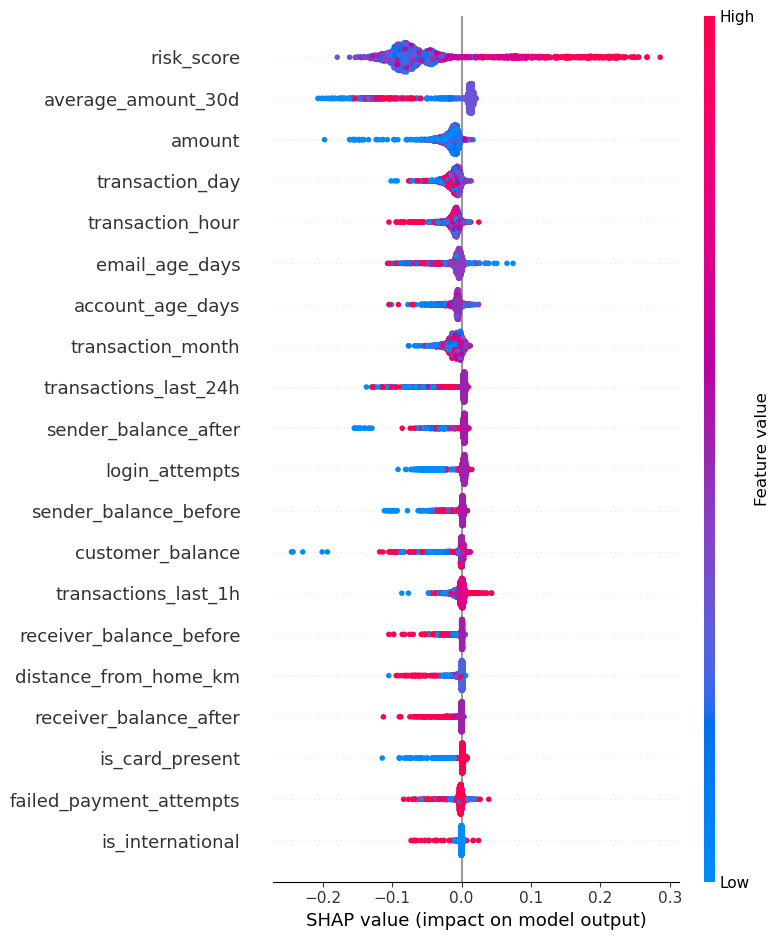

In [18]:
shap.summary_plot(
    fraud_shap_values,
    X_shap
)

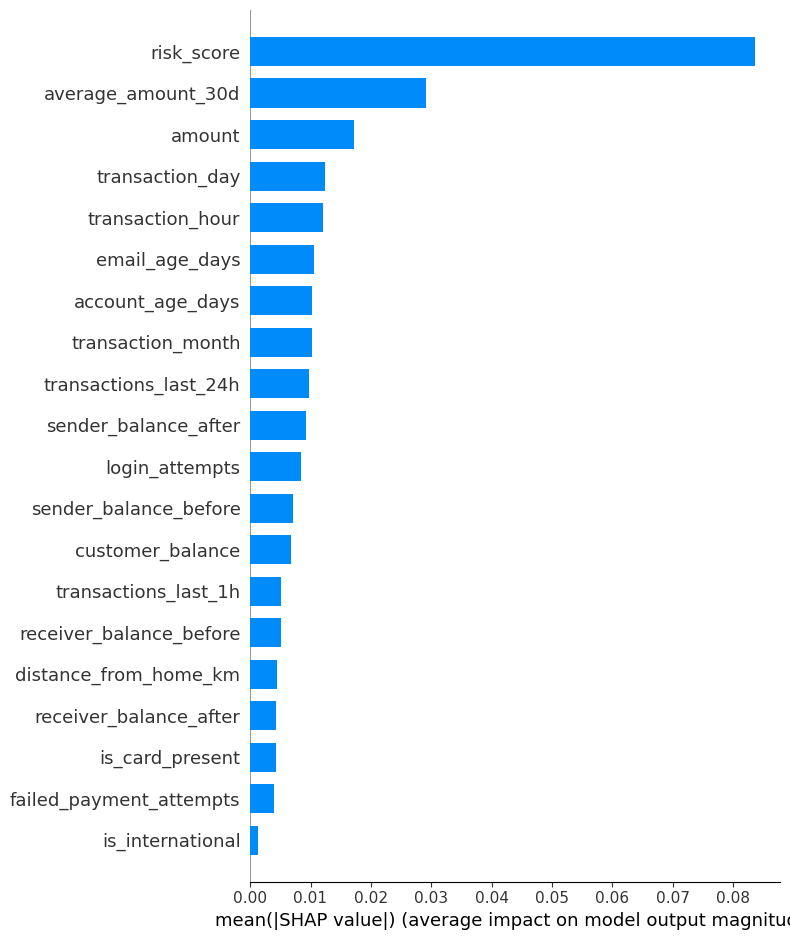

In [19]:
shap.summary_plot(
    fraud_shap_values,
    X_shap,
    plot_type="bar"
)

In [20]:
global_shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_absolute_shap": np.abs(
        fraud_shap_values
    ).mean(axis=0)
})

global_shap_importance = (
    global_shap_importance
    .sort_values(
        "mean_absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    global_shap_importance.head(20)
)

,feature,mean_absolute_shap
0,risk_score,0.083620
1,average_amount_30d,0.029112
2,amount,0.017220
3,transaction_day,0.012397
4,transaction_hour,0.012040
5,email_age_days,0.010541
6,account_age_days,0.010279
7,transaction_month,0.010253
8,transactions_last_24h,0.009704
9,sender_balance_after,0.009224


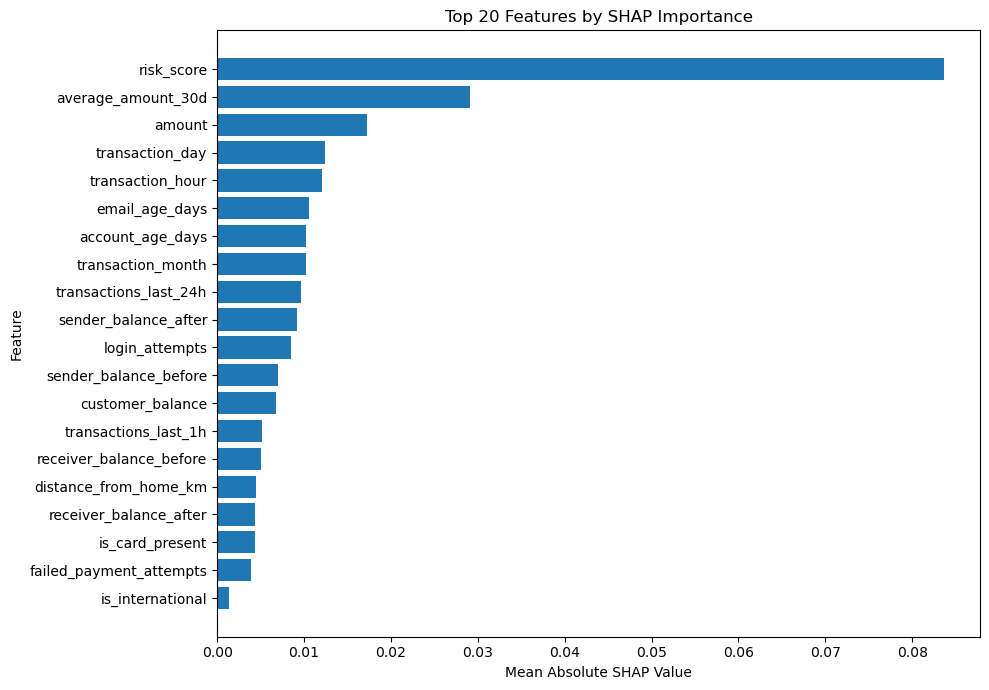

In [21]:
top_20 = (
    global_shap_importance
    .head(20)
    .sort_values(
        "mean_absolute_shap"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_20["feature"],
    top_20["mean_absolute_shap"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 20 Features by SHAP Importance"
)

plt.tight_layout()

plt.show()

In [22]:
transaction_position = 0

transaction_features = (
    X_shap.iloc[
        transaction_position
    ]
)

transaction_shap = (
    fraud_shap_values[
        transaction_position
    ]
)

display(
    transaction_features.to_frame(
        name="feature_value"
    )
)

,feature_value
amount,151.25
is_international,0.00
is_card_present,1.00
transactions_last_24h,4.00
average_amount_30d,144.94
risk_score,18.00
transaction_hour,15.00
transaction_day,20.00
transaction_month,5.00
sender_balance_before,195364.11


In [23]:
individual_explanation = pd.DataFrame({
    "feature": X_shap.columns,
    "feature_value": transaction_features.values,
    "shap_value": transaction_shap
})

individual_explanation[
    "absolute_shap"
] = np.abs(
    individual_explanation[
        "shap_value"
    ]
)

individual_explanation = (
    individual_explanation
    .sort_values(
        "absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

individual_explanation[
    "effect"
] = np.where(
    individual_explanation[
        "shap_value"
    ] > 0,
    "Increases fraud prediction",
    "Decreases fraud prediction"
)

display(
    individual_explanation.head(15)
)

,feature,feature_value,shap_value,absolute_shap,effect
0,risk_score,18.00,-0.054527,0.054527,Decreases fraud prediction
1,receiver_balance_after,294870.81,-0.051290,0.051290,Decreases fraud prediction
2,login_attempts,1.00,-0.044386,0.044386,Decreases fraud prediction
3,receiver_balance_before,294719.56,-0.042103,0.042103,Decreases fraud prediction
4,amount,151.25,-0.020173,0.020173,Decreases fraud prediction
5,transaction_hour,15.00,-0.011639,0.011639,Decreases fraud prediction
6,account_age_days,1045.00,-0.011168,0.011168,Decreases fraud prediction
7,sender_balance_before,195364.11,-0.010701,0.010701,Decreases fraud prediction
8,average_amount_30d,144.94,0.010663,0.010663,Increases fraud prediction
9,email_age_days,1078.00,-0.007422,0.007422,Decreases fraud prediction


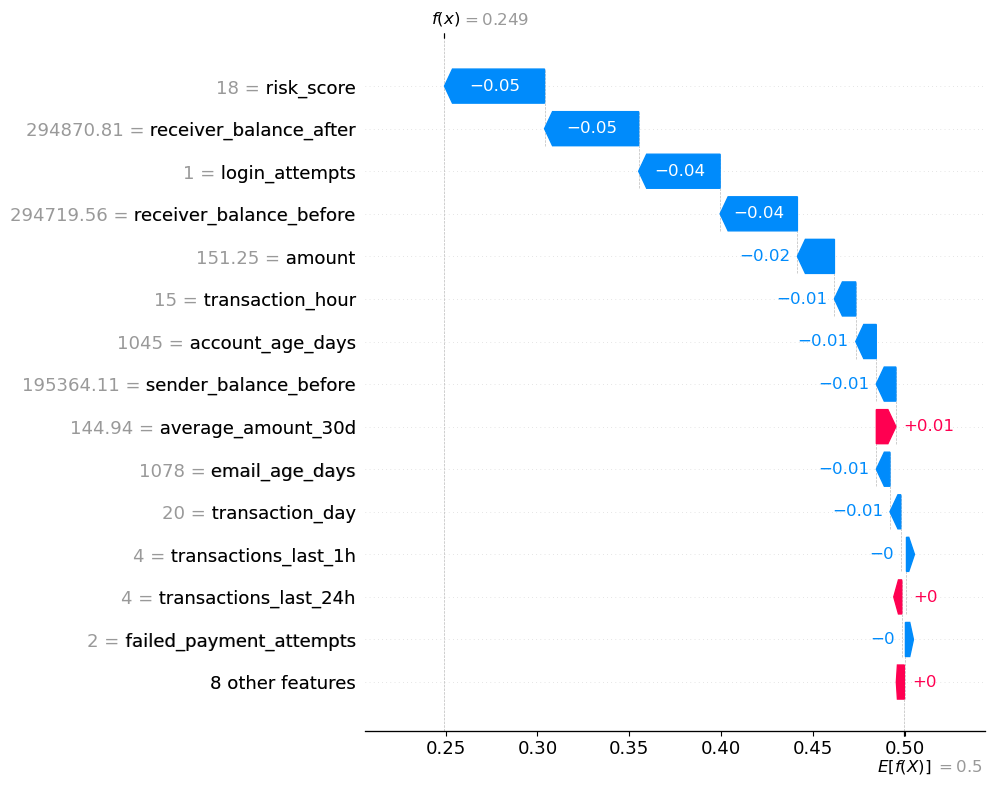

In [24]:
base_value = explainer.expected_value

if isinstance(
    base_value,
    (list, np.ndarray)
):
    base_value = base_value[1]

explanation = shap.Explanation(
    values=transaction_shap,
    base_values=base_value,
    data=transaction_features.values,
    feature_names=X_shap.columns
)

shap.plots.waterfall(
    explanation,
    max_display=15
)

In [25]:
fraud_validation_indices = (
    np.where(
        y_validation.values == 1
    )[0]
)

print(
    "Fraudulent validation transactions:",
    len(fraud_validation_indices)
)

Fraudulent validation transactions: 149


In [26]:
if len(fraud_validation_indices) == 0:

    raise ValueError(
        "No fraud transactions found in validation dataset."
    )

fraud_position = (
    fraud_validation_indices[0]
)

fraud_transaction = (
    X_validation.iloc[
        fraud_position
    ]
)

print(
    "Selected validation row:",
    fraud_position
)

display(
    fraud_transaction.to_frame(
        name="feature_value"
    )
)

Selected validation row: 10


,feature_value
amount,1106.92
is_international,0.00
is_card_present,1.00
transactions_last_24h,4.00
average_amount_30d,144.94
risk_score,76.00
transaction_hour,6.00
transaction_day,18.00
transaction_month,10.00
sender_balance_before,130766.45


In [27]:
fraud_transaction_df = (
    X_validation.iloc[
        [fraud_position]
    ]
)

fraud_shap_raw = (
    explainer.shap_values(
        fraud_transaction_df
    )
)

if isinstance(
    fraud_shap_raw,
    list
):

    if len(fraud_shap_raw) == 2:
        fraud_transaction_shap = (
            fraud_shap_raw[1][0]
        )
    else:
        fraud_transaction_shap = (
            fraud_shap_raw[0][0]
        )

elif isinstance(
    fraud_shap_raw,
    np.ndarray
):

    if fraud_shap_raw.ndim == 3:
        fraud_transaction_shap = (
            fraud_shap_raw[0, :, 1]
        )
    else:
        fraud_transaction_shap = (
            fraud_shap_raw[0]
        )

print(
    "Fraud transaction SHAP calculated."
)

Fraud transaction SHAP calculated.


In [28]:
fraud_explanation = pd.DataFrame({
    "feature": X_validation.columns,
    "feature_value": (
        fraud_transaction.values
    ),
    "shap_value": fraud_transaction_shap
})

fraud_explanation[
    "absolute_shap"
] = np.abs(
    fraud_explanation[
        "shap_value"
    ]
)

fraud_explanation = (
    fraud_explanation
    .sort_values(
        "absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

fraud_explanation[
    "effect"
] = np.where(
    fraud_explanation[
        "shap_value"
    ] > 0,
    "Increases fraud prediction",
    "Decreases fraud prediction"
)

display(
    fraud_explanation.head(15)
)

,feature,feature_value,shap_value,absolute_shap,effect
0,risk_score,76.00,0.222052,0.222052,Increases fraud prediction
1,amount,1106.92,-0.026980,0.026980,Decreases fraud prediction
2,transaction_month,10.00,-0.017014,0.017014,Decreases fraud prediction
3,account_age_days,311.00,-0.016528,0.016528,Decreases fraud prediction
4,average_amount_30d,144.94,0.015989,0.015989,Increases fraud prediction
5,email_age_days,1651.00,-0.008514,0.008514,Decreases fraud prediction
6,transaction_hour,6.00,0.007221,0.007221,Increases fraud prediction
7,failed_payment_attempts,2.00,0.006214,0.006214,Increases fraud prediction
8,sender_balance_after,130561.75,0.006034,0.006034,Increases fraud prediction
9,login_attempts,2.00,0.005950,0.005950,Increases fraud prediction


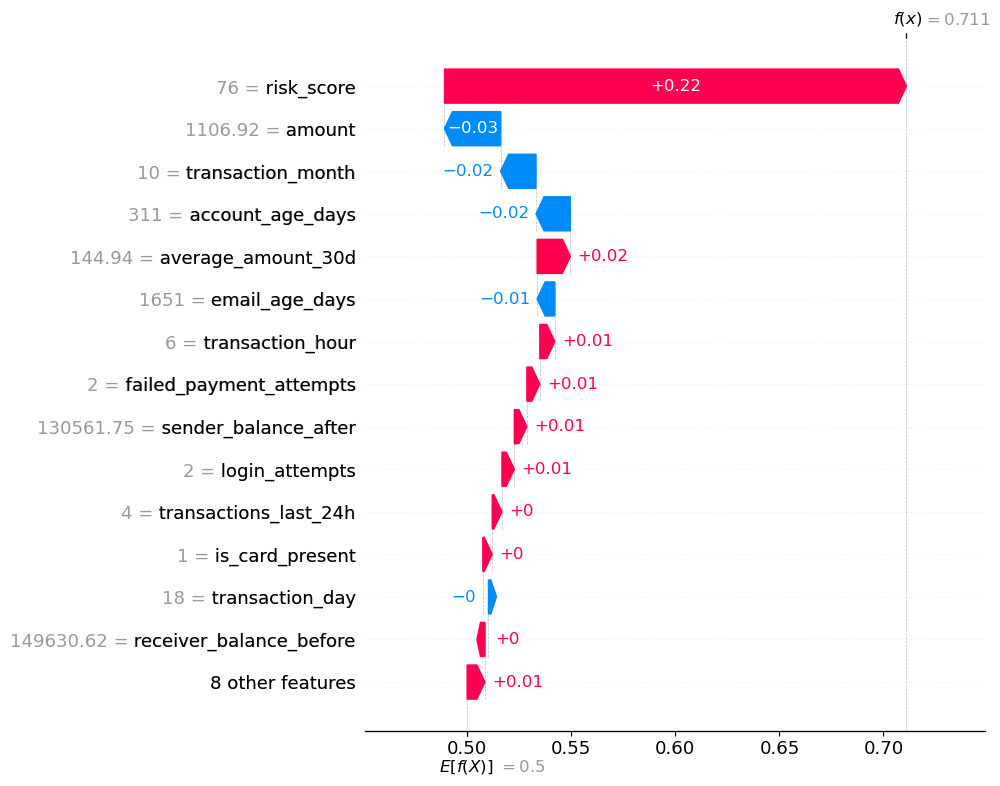

In [29]:
fraud_base_value = (
    explainer.expected_value
)

if isinstance(
    fraud_base_value,
    (list, np.ndarray)
):
    fraud_base_value = (
        fraud_base_value[1]
    )

fraud_explanation_object = shap.Explanation(
    values=fraud_transaction_shap,
    base_values=fraud_base_value,
    data=fraud_transaction.values,
    feature_names=X_validation.columns
)

shap.plots.waterfall(
    fraud_explanation_object,
    max_display=15
)

In [30]:
day17_results = pd.read_csv(
    "day17_hybrid_fraud_risk_results.csv"
)

print(
    day17_results.columns.tolist()
)

display(
    day17_results.head()
)

['actual_fraud', 'fraud_probability', 'isolation_anomaly_score', 'autoencoder_reconstruction_error', 'rf_score', 'isolation_score', 'autoencoder_score', 'hybrid_risk_score', 'hybrid_prediction', 'risk_level']


,actual_fraud,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,rf_score,isolation_score,autoencoder_score,hybrid_risk_score,hybrid_prediction,risk_level
0,0,0.005,-0.086159,0.289343,0.005,0.636679,0.371878,0.254639,0,Medium
1,0,0.005,-0.024963,0.487617,0.005,0.929810,0.700624,0.410109,0,Medium
2,0,0.005,-0.147066,0.157653,0.005,0.066836,0.100023,0.044215,0,Low
3,0,0.035,-0.119722,0.473307,0.035,0.299144,0.685708,0.263713,0,Medium
4,0,0.015,-0.148846,0.326386,0.015,0.055735,0.449121,0.133714,0,Low


In [34]:
print("Day 17 result columns:")
print("=" * 60)

for i, col in enumerate(day17_results.columns):
    print(i, ":", col)

Day 17 result columns:
0 : actual_fraud
1 : fraud_probability
2 : isolation_anomaly_score
3 : autoencoder_reconstruction_error
4 : rf_score
5 : isolation_score
6 : autoencoder_score
7 : hybrid_risk_score
8 : hybrid_prediction
9 : risk_level


In [35]:
print("\nFirst 5 rows:")
display(day17_results.head())


First 5 rows:


,actual_fraud,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,rf_score,isolation_score,autoencoder_score,hybrid_risk_score,hybrid_prediction,risk_level
0,0,0.005,-0.086159,0.289343,0.005,0.636679,0.371878,0.254639,0,Medium
1,0,0.005,-0.024963,0.487617,0.005,0.929810,0.700624,0.410109,0,Medium
2,0,0.005,-0.147066,0.157653,0.005,0.066836,0.100023,0.044215,0,Low
3,0,0.035,-0.119722,0.473307,0.035,0.299144,0.685708,0.263713,0,Medium
4,0,0.015,-0.148846,0.326386,0.015,0.055735,0.449121,0.133714,0,Low


In [36]:
print(day17_results.columns.tolist())

['actual_fraud', 'fraud_probability', 'isolation_anomaly_score', 'autoencoder_reconstruction_error', 'rf_score', 'isolation_score', 'autoencoder_score', 'hybrid_risk_score', 'hybrid_prediction', 'risk_level']


In [37]:
global_shap_importance.to_csv(
    "day19_shap_global_feature_importance.csv",
    index=False
)

print(
    "Saved global SHAP feature importance."
)

Saved global SHAP feature importance.


In [38]:
individual_explanation.to_csv(
    "day19_shap_individual_explanation.csv",
    index=False
)

print(
    "Saved individual SHAP explanation."
)

Saved individual SHAP explanation.


In [39]:
fraud_explanation.to_csv(
    "day19_shap_fraud_transaction_explanation.csv",
    index=False
)

print(
    "Saved fraud transaction explanation."
)

Saved fraud transaction explanation.


In [40]:
X_shap.to_csv(
    "day19_shap_validation_sample.csv",
    index=False
)

print(
    "Saved SHAP validation sample."
)

Saved SHAP validation sample.


In [41]:
print("=" * 65)
print("DAY 19 — SHAP EXPLAINABLE AI")
print("=" * 65)

print(
    "Training dataset: train_fraud_balanced.csv"
)

print(
    "Validation dataset: validation_fraud_dataset.csv"
)

print(
    "Target column:",
    target_column
)

print(
    "Training rows:",
    len(X_train)
)

print(
    "Validation rows:",
    len(X_validation)
)

print(
    "Number of features:",
    X_validation.shape[1]
)

print(
    "SHAP sample rows:",
    len(X_shap)
)

print("\nTop 10 SHAP features:")

display(
    global_shap_importance.head(10)
)

print(
    "\nDAY 19 SHAP ANALYSIS COMPLETED SUCCESSFULLY."
)

DAY 19 — SHAP EXPLAINABLE AI
Training dataset: train_fraud_balanced.csv
Validation dataset: validation_fraud_dataset.csv
Target column: is_fraud
Training rows: 79328
Validation rows: 8648
Number of features: 22
SHAP sample rows: 2000

Top 10 SHAP features:


,feature,mean_absolute_shap
0,risk_score,0.083620
1,average_amount_30d,0.029112
2,amount,0.017220
3,transaction_day,0.012397
4,transaction_hour,0.012040
5,email_age_days,0.010541
6,account_age_days,0.010279
7,transaction_month,0.010253
8,transactions_last_24h,0.009704
9,sender_balance_after,0.009224



DAY 19 SHAP ANALYSIS COMPLETED SUCCESSFULLY.
